In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Chemins
DATA_PATH = "../data/processed/dataset_final.csv"
MODEL_PATH = "../models"
REPORTS_PATH = "../reports/ml"
FIGURES_PATH = "../reports/figures/ml"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

# Chargement du dataset
df = pd.read_csv(DATA_PATH)

df["date_vente"] = pd.to_datetime(
    df["date_vente"],
    errors="coerce"
)

df["date_mois"] = pd.to_datetime(
    df["date_mois"],
    errors="coerce"
)

print("Dataset chargé avec succès")
print("Dimensions :", df.shape)
print("Période :", df["date_mois"].min(), "au", df["date_mois"].max())

df.head()

Dataset chargé avec succès
Dimensions : (28451, 24)
Période : 2007-01-01 00:00:00 au 2016-12-01 00:00:00


,transaction_id,date_vente,categorie_produit_1,categorie_produit_2,produit,quantite_vendue,trans_amount_weight,region,pays,code_pays,...,inflation,gdp_growth,temperature,precipitation,interest_rate,wheat_price,corn_price,soybean_price,trimestre,jour_semaine
0,319041,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),8.0,24.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
1,319042,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),4.0,12.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
2,319043,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),10.0,30.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
3,319103,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),1.0,3.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
4,319128,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),1.0,4.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2


In [2]:
# Variables Open Data

external_features = [
    "inflation",
    "gdp_growth",
    "temperature",
    "precipitation",
    "interest_rate",
    "wheat_price",
    "corn_price",
    "soybean_price"
]

# Agrégation mensuelle des ventes par produit et pays

monthly_sales = (
    df
    .groupby(
        [
            "date_mois",
            "produit",
            "code_pays"
        ],
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
)

# Informations sur les produits

product_info = (
    df
    .sort_values("date_vente")
    .drop_duplicates(
        subset=[
            "produit",
            "code_pays"
        ]
    )
    [
        [
            "produit",
            "code_pays",
            "categorie_produit_1",
            "categorie_produit_2",
            "region",
            "pays",
            "devise"
        ]
    ]
)

# Première et dernière vente de chaque série

series_periods = (
    monthly_sales
    .groupby(
        [
            "produit",
            "code_pays"
        ],
        as_index=False
    )
    .agg(
        date_debut=(
            "date_mois",
            "min"
        ),
        date_fin=(
            "date_mois",
            "max"
        )
    )
)

# Calendrier mensuel

calendar = pd.DataFrame({
    "date_mois": pd.date_range(
        start=df["date_mois"].min(),
        end=df["date_mois"].max(),
        freq="MS"
    )
})

# Toutes les combinaisons produit-pays-mois

panel = series_periods.merge(
    calendar,
    how="cross"
)

# Conservation de la période d'activité de chaque série

panel = panel[
    (
        panel["date_mois"]
        >= panel["date_debut"]
    )
    &
    (
        panel["date_mois"]
        <= panel["date_fin"]
    )
].copy()

panel = panel.drop(
    columns=[
        "date_debut",
        "date_fin"
    ]
)

# Données Open Data mensuelles par pays

external_data = (
    df
    .groupby(
        [
            "date_mois",
            "code_pays"
        ],
        as_index=False
    )[external_features]
    .mean()
)

# Liste des pays

countries = (
    df[
        ["code_pays"]
    ]
    .drop_duplicates()
)

# Calendrier Open Data complet pour chaque pays

external_full = countries.merge(
    calendar,
    how="cross"
)

external_full = external_full.merge(
    external_data,
    on=[
        "date_mois",
        "code_pays"
    ],
    how="left"
)

external_full = external_full.sort_values(
    [
        "code_pays",
        "date_mois"
    ]
)

# Remplissage des valeurs Open Data manquantes

external_full[external_features] = (
    external_full
    .groupby("code_pays")[external_features]
    .transform(
        lambda x: x.interpolate().ffill().bfill()
    )
)

# Décalage des Open Data d'un mois

external_lag_features = []

for colonne in external_features:

    nouvelle_colonne = (
        colonne
        + "_M1"
    )

    external_full[nouvelle_colonne] = (
        external_full
        .groupby("code_pays")[colonne]
        .shift(1)
    )

    external_lag_features.append(
        nouvelle_colonne
    )

# Fusion du panel avec les ventes

ml_data = panel.merge(
    monthly_sales,
    on=[
        "date_mois",
        "produit",
        "code_pays"
    ],
    how="left"
)

# Ajout des informations des produits

ml_data = ml_data.merge(
    product_info,
    on=[
        "produit",
        "code_pays"
    ],
    how="left"
)

# Ajout des données Open Data

ml_data = ml_data.merge(
    external_full,
    on=[
        "date_mois",
        "code_pays"
    ],
    how="left"
)

# Les mois sans vente prennent la valeur zéro

ml_data[
    [
        "quantite_vendue",
        "trans_amount_weight"
    ]
] = ml_data[
    [
        "quantite_vendue",
        "trans_amount_weight"
    ]
].fillna(0)

# Variables temporelles

ml_data["annee"] = (
    ml_data["date_mois"].dt.year
)

ml_data["mois"] = (
    ml_data["date_mois"].dt.month
)

ml_data["trimestre"] = (
    ml_data["date_mois"].dt.quarter
)

# Colonnes de regroupement

group_cols = [
    "produit",
    "code_pays"
]

# Tri avant le calcul des retards

ml_data = ml_data.sort_values(
    group_cols
    + ["date_mois"]
)

# Quantité vendue le mois précédent

ml_data["vente_M1"] = (
    ml_data
    .groupby(group_cols)["quantite_vendue"]
    .shift(1)
)

# Quantité vendue deux mois avant

ml_data["vente_M2"] = (
    ml_data
    .groupby(group_cols)["quantite_vendue"]
    .shift(2)
)

# Quantité vendue douze mois avant

ml_data["vente_M12"] = (
    ml_data
    .groupby(group_cols)["quantite_vendue"]
    .shift(12)
)

# Moyenne des trois mois précédents

ml_data["moyenne_mobile_3"] = (
    ml_data
    .groupby(group_cols)["quantite_vendue"]
    .transform(
        lambda x: (
            x
            .shift(1)
            .rolling(3)
            .mean()
        )
    )
)

# Variables de retard des ventes

lag_features = [
    "vente_M1",
    "vente_M2",
    "vente_M12",
    "moyenne_mobile_3"
]

# Suppression des lignes sans historique suffisant

ml_data = ml_data.dropna(
    subset=(
        lag_features
        + external_lag_features
    )
)

# Tri chronologique final

ml_data = ml_data.sort_values(
    [
        "date_mois",
        "produit",
        "code_pays"
    ]
)

ml_data = ml_data.reset_index(
    drop=True
)

# Sauvegarde du dataset Machine Learning

ml_data.to_csv(
    "../data/processed/dataset_model_ml.csv",
    index=False
)

# Pourcentage de mois sans vente

pourcentage_zero = (
    ml_data["quantite_vendue"]
    .eq(0)
    .mean()
    * 100
)

print("Dataset ML créé")
print("Dimensions :", ml_data.shape)

print(
    "Nombre de produits :",
    ml_data["produit"].nunique()
)

print(
    "Pays :",
    ml_data["code_pays"].unique()
)

print(
    "Pourcentage de mois sans vente :",
    round(pourcentage_zero, 2),
    "%"
)

print(
    "Variables Open Data décalées :",
    external_lag_features
)

print(
    "Valeurs manquantes :",
    ml_data[
        lag_features
        + external_lag_features
    ]
    .isna()
    .sum()
    .sum()
)

ml_data.head()

Dataset ML créé
Dimensions : (2157, 33)
Nombre de produits : 29
Pays : ['USA' 'CAN']
Pourcentage de mois sans vente : 53.59 %
Variables Open Data décalées : ['inflation_M1', 'gdp_growth_M1', 'temperature_M1', 'precipitation_M1', 'interest_rate_M1', 'wheat_price_M1', 'corn_price_M1', 'soybean_price_M1']
Valeurs manquantes : 0


,produit,code_pays,date_mois,quantite_vendue,trans_amount_weight,categorie_produit_1,categorie_produit_2,region,pays,devise,...,wheat_price_M1,corn_price_M1,soybean_price_M1,annee,mois,trimestre,vente_M1,vente_M2,vente_M12,moyenne_mobile_3
0,combine harvester (cereals) & cotton picker,USA,2008-01-01,336.0,2016.0,agriculture,"cereals, cotton, & feed/forage harvesting",Northern America,united states,EUR,...,339.225696,180.283264,423.080741,2008,1,1,264.0,340.0,259.0,214.000000
1,feller bunchers (machine),USA,2008-01-01,2.0,6.0,agriculture,forestry,Northern America,united states,EUR,...,339.225696,180.283264,423.080741,2008,1,1,0.0,0.0,4.0,0.000000
2,sprayer (self propelled),USA,2008-01-01,92.0,293.0,agriculture,soil & crop treatment,Northern America,united states,EUR,...,339.225696,180.283264,423.080741,2008,1,1,79.0,54.0,56.0,62.333333
3,straddle (over-the-row) fruit harvester (self ...,USA,2008-01-01,30.0,56.0,agriculture,"wine, fruit, vegetable & cane equipment",Northern America,united states,EUR,...,339.225696,180.283264,423.080741,2008,1,1,16.0,29.0,9.0,21.666667
4,"timber handler, log forwarder (machine)",CAN,2008-01-01,0.0,0.0,agriculture,forestry,Northern America,canada,EUR,...,311.306342,188.836374,425.365193,2008,1,1,0.0,3.0,4.0,1.000000


In [3]:
# Variable cible

target = "quantite_vendue"

# Variables numériques

numeric_features = [
    "annee",
    "inflation_M1",
    "gdp_growth_M1",
    "temperature_M1",
    "precipitation_M1",
    "interest_rate_M1",
    "wheat_price_M1",
    "corn_price_M1",
    "soybean_price_M1",
    "vente_M1",
    "vente_M2",
    "vente_M12",
    "moyenne_mobile_3"
]

# Variables catégorielles

categorical_features = [
    "mois",
    "categorie_produit_2",
    "produit",
    "code_pays"
]

# Toutes les variables explicatives

features = (
    numeric_features
    + categorical_features
)

X = ml_data[features]
y = ml_data[target]

print("Variable cible :", target)

print(
    "Nombre de variables explicatives :",
    len(features)
)

print(
    "Variables numériques :",
    len(numeric_features)
)

print(
    "Variables catégorielles :",
    len(categorical_features)
)

print(
    "Variables Open Data décalées :",
    external_lag_features
)

Variable cible : quantite_vendue
Nombre de variables explicatives : 17
Variables numériques : 13
Variables catégorielles : 4
Variables Open Data décalées : ['inflation_M1', 'gdp_growth_M1', 'temperature_M1', 'precipitation_M1', 'interest_rate_M1', 'wheat_price_M1', 'corn_price_M1', 'soybean_price_M1']


In [4]:
# Les deux dernières années sont utilisées pour le test

split_date = (
    ml_data["date_mois"].max()
    - pd.DateOffset(months=23)
)

train_data = ml_data[
    ml_data["date_mois"] < split_date
].copy()

test_data = ml_data[
    ml_data["date_mois"] >= split_date
].copy()

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Date de séparation :", split_date)

print("\nTrain :", X_train.shape)
print("Test :", X_test.shape)

print("\nPériode train :")
print(
    train_data["date_mois"].min(),
    "au",
    train_data["date_mois"].max()
)

print("\nPériode test :")
print(
    test_data["date_mois"].min(),
    "au",
    test_data["date_mois"].max()
)

assert (
    train_data["date_mois"].max()
    < test_data["date_mois"].min()
)

Date de séparation : 2015-01-01 00:00:00

Train : (1672, 17)
Test : (485, 17)

Période train :
2008-01-01 00:00:00 au 2014-12-01 00:00:00

Période test :
2015-01-01 00:00:00 au 2016-12-01 00:00:00


In [5]:
# Prétraitement des variables

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Préprocesseur créé")

Préprocesseur créé


In [6]:
# Modèles de machine learning

models = {
    "Ridge Regression": Ridge(
        alpha=1.0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

# Résultat du modèle naïf
# Il prédit la même quantité que le mois précédent

baseline_pred = X_test["vente_M1"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

baseline_wape = (
    np.abs(y_test.values - baseline_pred).sum()
    / y_test.sum()
    * 100
)

results = [
    {
        "model": "Naive M1",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
        "WAPE": baseline_wape
    }
]

trained_models = {}

# Entraînement des modèles

for model_name, model in models.items():

    print("\nEntraînement :", model_name)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(X_test)

    # Une quantité prédite ne peut pas être négative

    y_pred = np.maximum(
        y_pred,
        0
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    wape = (
        np.abs(y_test.values - y_pred).sum()
        / y_test.sum()
        * 100
    )

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE": wape
    })

    trained_models[model_name] = pipeline

    print("MAE :", round(mae, 3))
    print("RMSE :", round(rmse, 3))
    print("R2 :", round(r2, 3))
    print("WAPE :", round(wape, 2), "%")

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df.to_csv(
    f"{REPORTS_PATH}/model_results.csv",
    index=False
)

results_df


Entraînement : Ridge Regression
MAE : 23.511
RMSE : 82.329
R2 : 0.857
WAPE : 42.88 %

Entraînement : Random Forest


MAE : 20.004
RMSE : 78.101
R2 : 0.872
WAPE : 36.48 %

Entraînement : Gradient Boosting


MAE : 19.657
RMSE : 77.526
R2 : 0.874
WAPE : 35.85 %


,model,MAE,RMSE,R2,WAPE
0,Gradient Boosting,19.657198,77.525792,0.873507,35.849218
1,Random Forest,20.003727,78.101240,0.871622,36.481189
2,Ridge Regression,23.511114,82.329182,0.857347,42.877681
3,Naive M1,20.315464,87.026634,0.840603,37.049710


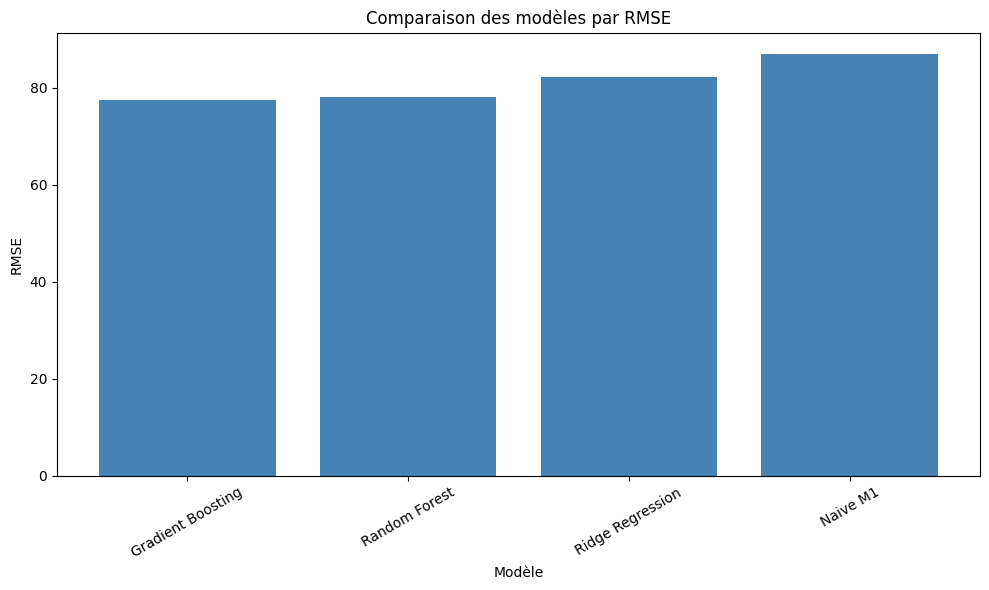

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["model"],
    results_df["RMSE"],
    color="steelblue"
)

plt.title("Comparaison des modèles par RMSE")
plt.xlabel("Modèle")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/model_comparison_rmse.png"
)

plt.show()
plt.close()

In [8]:
# Sélection du meilleur modèle entraîné

trained_results = results_df[
    results_df["model"] != "Naive M1"
].sort_values("RMSE")

best_model_name = (
    trained_results.iloc[0]["model"]
)

best_model = trained_models[
    best_model_name
]

# Comparaison avec le modèle naïf

best_rmse = trained_results.iloc[0]["RMSE"]

baseline_rmse = results_df.loc[
    results_df["model"] == "Naive M1",
    "RMSE"
].iloc[0]

amelioration_rmse = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
    * 100
)

# Sauvegarde

joblib.dump(
    best_model,
    f"{MODEL_PATH}/best_model.pkl"
)

print("Meilleur modèle :", best_model_name)
print("RMSE du modèle naïf :", round(baseline_rmse, 3))
print("RMSE du meilleur modèle :", round(best_rmse, 3))

print(
    "Amélioration par rapport au modèle naïf :",
    round(amelioration_rmse, 2),
    "%"
)

print(
    "Modèle sauvegardé dans :",
    f"{MODEL_PATH}/best_model.pkl"
)

Meilleur modèle : Gradient Boosting
RMSE du modèle naïf : 87.027
RMSE du meilleur modèle : 77.526
Amélioration par rapport au modèle naïf : 10.92 %
Modèle sauvegardé dans : ../models/best_model.pkl


In [9]:
# Prédictions du meilleur modèle

y_pred_best = best_model.predict(
    X_test
)

y_pred_best = np.maximum(
    y_pred_best,
    0
)

predictions_df = test_data.copy()

predictions_df["quantite_reelle"] = (
    y_test.values
)

predictions_df["quantite_predite"] = (
    y_pred_best
)

predictions_df["erreur"] = (
    predictions_df["quantite_reelle"]
    - predictions_df["quantite_predite"]
)

predictions_df["erreur_absolue"] = (
    predictions_df["erreur"].abs()
)

predictions_df["modele"] = (
    best_model_name
)

predictions_df.to_csv(
    f"{REPORTS_PATH}/predictions_test.csv",
    index=False
)

print("Prédictions sauvegardées")
print("Nombre de prédictions :", len(predictions_df))

predictions_df[
    [
        "date_mois",
        "produit",
        "code_pays",
        "quantite_reelle",
        "quantite_predite",
        "erreur",
        "erreur_absolue"
    ]
].head()

Prédictions sauvegardées
Nombre de prédictions : 485


,date_mois,produit,code_pays,quantite_reelle,quantite_predite,erreur,erreur_absolue
1672,2015-01-01,aerial cableway,CAN,0.0,5.180459,-5.180459,5.180459
1673,2015-01-01,cattle feeder mixer (self propelled),CAN,0.0,6.036701,-6.036701,6.036701
1674,2015-01-01,cattle feeder mixer (self propelled),USA,0.0,5.631231,-5.631231,5.631231
1675,2015-01-01,combine harvester (cereals) & cotton picker,USA,1239.0,607.804005,631.195995,631.195995
1676,2015-01-01,feller bunchers (machine),CAN,0.0,5.180459,-5.180459,5.180459


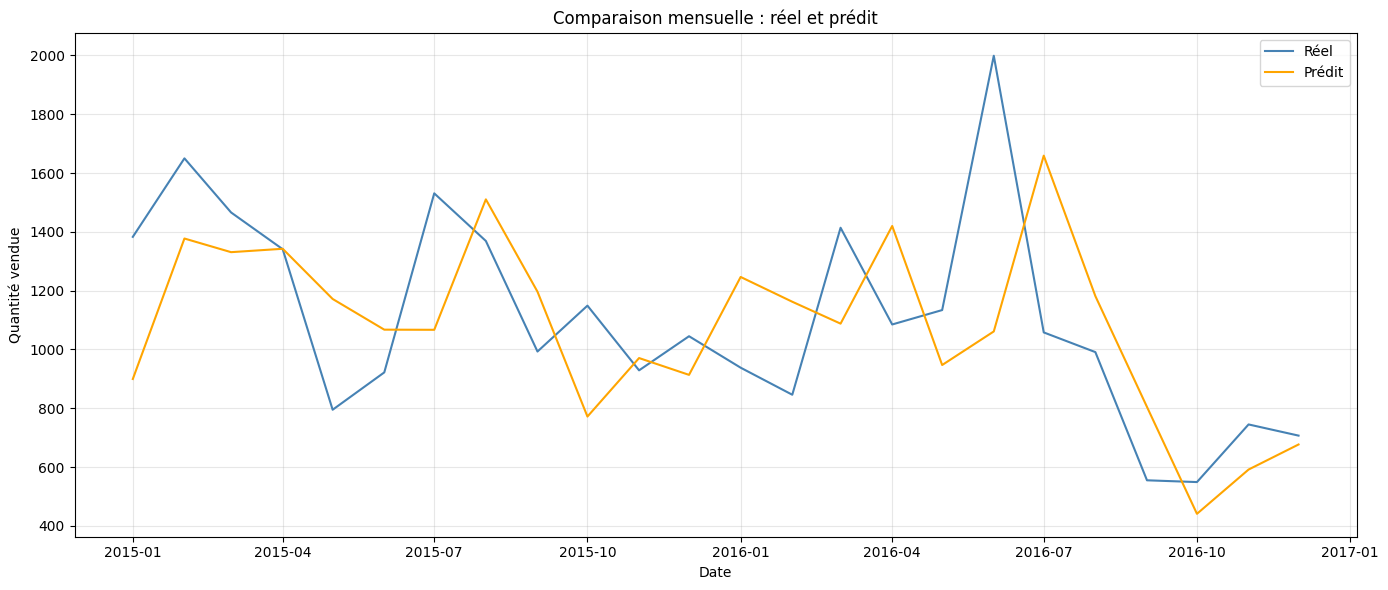

,date_mois,quantite_reelle,quantite_predite
0,2015-01-01,1383.0,899.553198
1,2015-02-01,1650.0,1377.337304
2,2015-03-01,1466.0,1330.926924
3,2015-04-01,1341.0,1342.424138
4,2015-05-01,795.0,1171.731980


In [10]:
# Total réel et prédit par mois

monthly_predictions = (
    predictions_df
    .groupby(
        "date_mois",
        as_index=False
    )
    .agg({
        "quantite_reelle": "sum",
        "quantite_predite": "sum"
    })
)

monthly_predictions.to_csv(
    f"{REPORTS_PATH}/predictions_monthly.csv",
    index=False
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_predictions["date_mois"],
    monthly_predictions["quantite_reelle"],
    label="Réel",
    color="steelblue"
)

plt.plot(
    monthly_predictions["date_mois"],
    monthly_predictions["quantite_predite"],
    label="Prédit",
    color="orange"
)

plt.title("Comparaison mensuelle : réel et prédit")
plt.xlabel("Date")
plt.ylabel("Quantité vendue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/real_vs_predicted.png"
)

plt.show()
plt.close()

monthly_predictions.head()

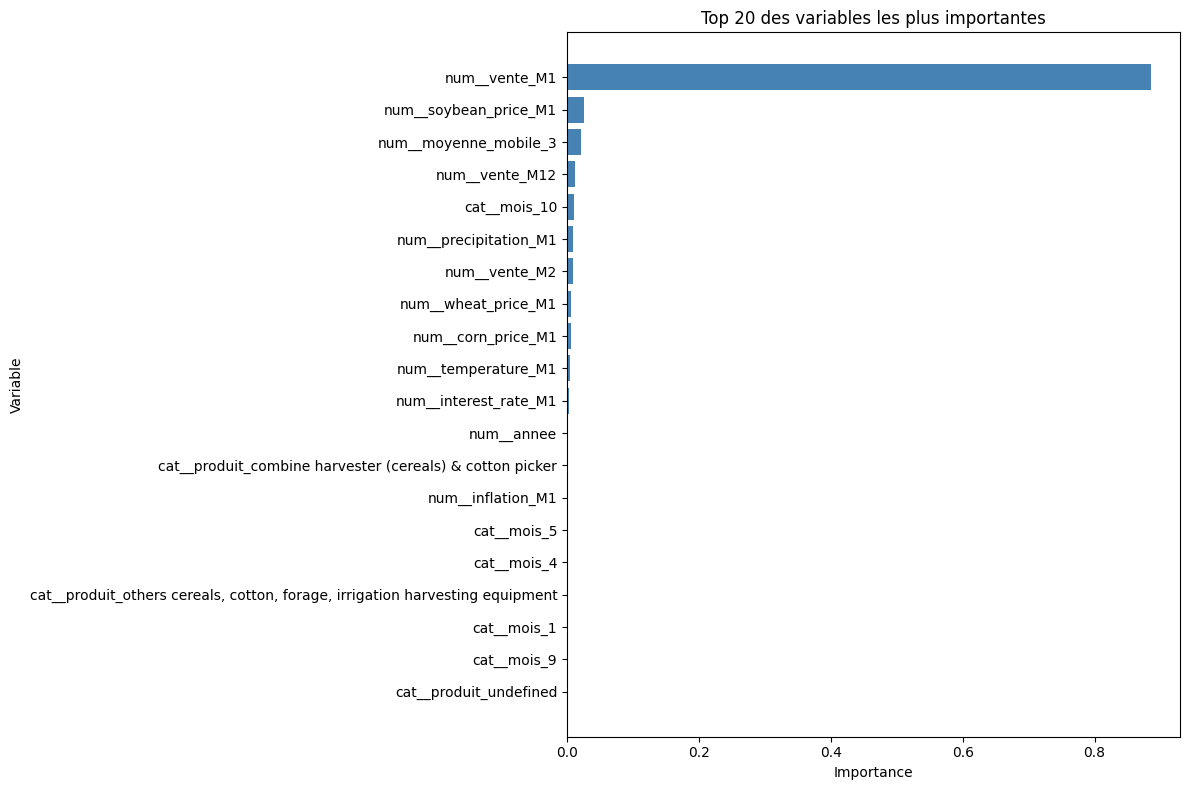

,feature,importance
9,num__vente_M1,0.885272
8,num__soybean_price_M1,0.026148
12,num__moyenne_mobile_3,0.020439
11,num__vente_M12,0.011408
22,cat__mois_10,0.010472
4,num__precipitation_M1,0.009335
10,num__vente_M2,0.008796
6,num__wheat_price_M1,0.006686
7,num__corn_price_M1,0.006354
3,num__temperature_M1,0.005161


In [11]:
# Noms des variables après le prétraitement

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

model_step = best_model.named_steps["model"]

# Importance des variables

if hasattr(model_step, "feature_importances_"):

    importances = (
        model_step.feature_importances_
    )

else:

    importances = np.abs(
        model_step.coef_
    )

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .head(20)
)

importance_df.to_csv(
    f"{REPORTS_PATH}/feature_importance.csv",
    index=False
)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_df["feature"],
    importance_df["importance"],
    color="steelblue"
)

plt.title("Top 20 des variables les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/feature_importance.png"
)

plt.show()
plt.close()

importance_df

In [12]:
expected_files = [
    "../data/processed/dataset_model_ml.csv",
    f"{REPORTS_PATH}/model_results.csv",
    f"{REPORTS_PATH}/predictions_test.csv",
    f"{REPORTS_PATH}/predictions_monthly.csv",
    f"{REPORTS_PATH}/feature_importance.csv",
    f"{FIGURES_PATH}/model_comparison_rmse.png",
    f"{FIGURES_PATH}/real_vs_predicted.png",
    f"{FIGURES_PATH}/feature_importance.png",
    f"{MODEL_PATH}/best_model.pkl"
]

for file in expected_files:
    print(file, os.path.exists(file))

../data/processed/dataset_model_ml.csv True
../reports/ml/model_results.csv True
../reports/ml/predictions_test.csv True
../reports/ml/predictions_monthly.csv True
../reports/ml/feature_importance.csv True
../reports/figures/ml/model_comparison_rmse.png True
../reports/figures/ml/real_vs_predicted.png True
../reports/figures/ml/feature_importance.png True
../models/best_model.pkl True
